# 10. Topological embedding and directional feature importance in ensemble classifiers for multi-class classification.

***Métodos:*** Implementamos un enfoque basado en LAVA (Local Correlated Feature Aggregation) para crear características latentes. Estas nuevas características, que capturan información de correlación multivariante, se generaron aplicando PCA sobre los grupos de variables correlacionadas (LAVA groups). 

Posteriormente, se entrenó un modelo de `Stacking`, usando como modelos base los modelos que consiguieron los mejores scores para la tarea de clasificación: `k-NN`, `Random Forest` y `XGBoost`; y el meta-modelo utilizado fue `XGBoost`. La entrada para los modelos base fue el conjunto de datos original junto con estas características latentes. Los modelos fueron entrenados y evaluados en un dataset de riesgo crediticio con tres clases: Good, Standard, y Poor.

In [1]:
import numpy as np
import pandas as pd

from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

from scipy.sparse import issparse

from xgboost import XGBClassifier

In [2]:
# ============================================
# 1. Cargar datos
# ============================================


df = pd.read_pickle("data_limpia.pkl")

target_col = "credit_score"
y_raw = df[target_col].copy()
X = df.drop(columns=[target_col]).copy()

print("Shape df:", df.shape)
print("Columnas:", df.columns.tolist())
print("Clases en credit_score:", y_raw.value_counts())


Shape df: (100000, 29)
Columnas: ['age', 'monthly_inhand_salary', 'num_bank_accounts', 'num_credit_card', 'interest_rate', 'delay_from_due_date', 'num_of_delayed_payment', 'changed_credit_limit', 'num_credit_inquiries', 'outstanding_debt', 'credit_utilization_ratio', 'credit_history_age', 'total_emi_per_month', 'amount_invested_monthly', 'monthly_balance', 'occupation', 'credit_mix', 'payment_of_min_amount', 'payment_behaviour', 'not_specified', 'credit_builder_loan', 'personal_loan', 'debt_consolidation_loan', 'student_loan', 'payday_loan', 'mortgage_loan', 'auto_loan', 'home_equity_loan', 'credit_score']
Clases en credit_score: credit_score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


In [3]:
# ============================================
# 2. Codificar y como variable ordinal
# ============================================

class_order = ["Good", "Standard", "Poor"] 
mapping = {cls: i for i, cls in enumerate(class_order)}
y = y_raw.map(mapping)

print("Mapping:", mapping)
print("Distribución y:", Counter(y))


Mapping: {'Good': 0, 'Standard': 1, 'Poor': 2}
Distribución y: Counter({1: 53174, 2: 28998, 0: 17828})


In [4]:
# ============================================
# 3. Train/Test split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)


X_train: (70000, 28) X_test: (30000, 28)


In [5]:

# Seleccionamos las variables numericas a estandarizar
num_cols=['age', 'monthly_inhand_salary',
          'num_bank_accounts', 'num_credit_card', 'interest_rate',
          'delay_from_due_date', 'num_of_delayed_payment','changed_credit_limit',
          'num_credit_inquiries', 'outstanding_debt', 'credit_utilization_ratio',
          'credit_history_age','total_emi_per_month', 'amount_invested_monthly',
          'monthly_balance']

# Seleccionamos las variables categóricas a codificar
cat_cols=['occupation', 'credit_mix', 'payment_of_min_amount','payment_behaviour']
# Se no se toman las variables binarias ya que estas ya pueden considerarse
# como codificadas



In [6]:
# ============================================
# 5. Construir grafo de correlaciones (LAVA)
# ============================================

def build_lava_groups(X_num: pd.DataFrame, corr_threshold=0.5, min_group_size=2):
    """
    Construye grupos de variables (LAVA groups) a partir de correlaciones.
    - X_num: dataframe sólo con columnas numéricas.
    - corr_threshold: umbral |corr| a partir del cual conectamos dos features.
    - min_group_size: tamaño mínimo para formar grupo LAVA.
    
    Devuelve: lista de grupos, cada grupo es lista de nombres de columnas.
    """
    cols = X_num.columns.tolist()
    corr = X_num.corr().values
    n = len(cols)
    
    # grafo no dirigido por matriz de adyacencia booleana
    adj = [[False]*n for _ in range(n)]
    for i in range(n):
        for j in range(i+1, n):
            if abs(corr[i, j]) >= corr_threshold:
                adj[i][j] = True
                adj[j][i] = True
    
    visited = [False]*n
    groups = []
    
    for i in range(n):
        if not visited[i]:
            # BFS/DFS para componente conexa
            stack = [i]
            comp = []
            visited[i] = True
            while stack:
                u = stack.pop()
                comp.append(u)
                for v in range(n):
                    if adj[u][v] and not visited[v]:
                        visited[v] = True
                        stack.append(v)
            if len(comp) >= min_group_size:
                group_cols = [cols[idx] for idx in comp]
                groups.append(group_cols)
    
    return groups

X_train_num = X_train[num_cols].copy()
lava_groups = build_lava_groups(X_train_num, corr_threshold=0.5, min_group_size=2)

print("Número de grupos LAVA encontrados:", len(lava_groups))
for i, g in enumerate(lava_groups):
    print(f"Grupo {i}: {g}")

Número de grupos LAVA encontrados: 2
Grupo 0: ['monthly_inhand_salary', 'monthly_balance', 'amount_invested_monthly']
Grupo 1: ['num_bank_accounts', 'num_of_delayed_payment', 'outstanding_debt', 'credit_history_age', 'num_credit_inquiries', 'delay_from_due_date', 'interest_rate', 'num_credit_card']


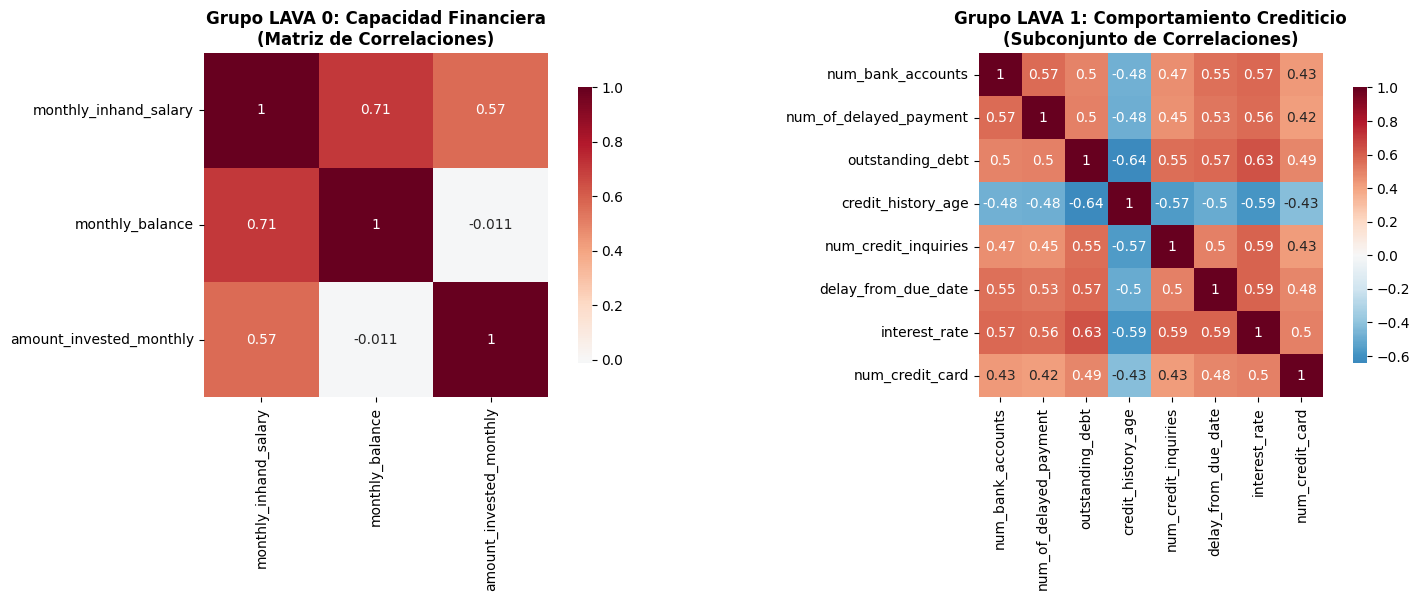

🔍 ANÁLISIS GRUPOS LAVA:
• Grupo 0 muestra correlaciones fuertes (>0.5) entre variables de capacidad financiera
• Grupo 1 presenta patrones de correlación complejos en comportamiento crediticio
• Estos grupos capturan dimensiones latentes del perfil crediticio del cliente


In [7]:
# ============================================
# 5.1 Visualización de Correlaciones LAVA
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap de correlaciones para los grupos LAVA identificados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grupo 0 - Capacidad Financiera
grupo0_corr = X_train[['monthly_inhand_salary', 'monthly_balance', 'amount_invested_monthly']].corr()
sns.heatmap(grupo0_corr, annot=True, cmap='RdBu_r', center=0, ax=ax1, 
            square=True, cbar_kws={"shrink": .8})
ax1.set_title('Grupo LAVA 0: Capacidad Financiera\n(Matriz de Correlaciones)', fontsize=12, fontweight='bold')

# Grupo 1 - Comportamiento Crediticio  
grupo1_subset = ['num_bank_accounts', 'num_of_delayed_payment', 'outstanding_debt', 
                'credit_history_age', 'num_credit_inquiries', 'delay_from_due_date',
                'interest_rate', 'num_credit_card']
grupo1_corr = X_train[grupo1_subset].corr()
sns.heatmap(grupo1_corr, annot=True, cmap='RdBu_r', center=0, ax=ax2,
            square=True, cbar_kws={"shrink": .8})
ax2.set_title('Grupo LAVA 1: Comportamiento Crediticio\n(Subconjunto de Correlaciones)', 
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("🔍 ANÁLISIS GRUPOS LAVA:")
print("• Grupo 0 muestra correlaciones fuertes (>0.5) entre variables de capacidad financiera")
print("• Grupo 1 presenta patrones de correlación complejos en comportamiento crediticio")
print("• Estos grupos capturan dimensiones latentes del perfil crediticio del cliente")

In [8]:
# ============================================
# 6. Ajustar PCA para cada grupo LAVA
# ============================================

class LavaLatentBuilder:
    """
    Guarda para cada grupo:
    - nombres de columnas
    - StandardScaler
    - PCA(1)
    """
    def __init__(self, groups):
        self.groups = groups
        self.scalers = []
        self.pcas = []
    
    def fit(self, X_num: pd.DataFrame):
        self.scalers = []
        self.pcas = []
        for group in self.groups:
            scaler = StandardScaler()
            pca = PCA(n_components=1, random_state=42)
            Xg = X_num[group].values
            Xg_scaled = scaler.fit_transform(Xg)
            pca.fit(Xg_scaled)
            self.scalers.append(scaler)
            self.pcas.append(pca)
        return self
    
    def transform(self, X_num: pd.DataFrame):
        latent_list = []
        for group, scaler, pca in zip(self.groups, self.scalers, self.pcas):
            Xg = X_num[group].values
            Xg_scaled = scaler.transform(Xg)
            z = pca.transform(Xg_scaled)  # shape (n_samples, 1)
            latent_list.append(z)
        if len(latent_list) == 0:
            # no hay grupos
            return np.zeros((X_num.shape[0], 0))
        Z = np.hstack(latent_list)  # (n_samples, n_groups)
        return Z

# Crear y ajustar el builder
lava_builder = LavaLatentBuilder(lava_groups)
lava_builder.fit(X_train_num)

# Transformar train y test
Z_train = lava_builder.transform(X_train_num)
Z_test = lava_builder.transform(X_test[num_cols])

print("Shape Z_train (LAVA latents):", Z_train.shape)
print("Shape Z_test (LAVA latents):", Z_test.shape)


Shape Z_train (LAVA latents): (70000, 2)
Shape Z_test (LAVA latents): (30000, 2)


In [9]:
# ============================================
# 7. Concatenar grupos LAVA con X_train y X_test
# ============================================

X_train_lava=pd.concat([X_train, pd.DataFrame(Z_train, 
                          columns=[f'lava_latent_{i}' for i in range(Z_train.shape[1])],
                          index=X_train.index)], axis=1)
X_test_lava=pd.concat([X_test, pd.DataFrame(Z_test, 
                          columns=[f'lava_latent_{i}' for i in range(Z_test.shape[1])],
                          index=X_test.index)], axis=1)
print("X_train_lava shape:", X_train_lava.shape)
print("X_test_lava shape:", X_test_lava.shape)


X_train_lava shape: (70000, 30)
X_test_lava shape: (30000, 30)


In [10]:
num_cols.append('lava_latent_0')  # Añadir las nuevas columnas LAVA a num_cols
num_cols.append('lava_latent_1')  # Añadir las nuevas columnas LAVA a num_cols

## Stacking con RandomizedSearchCV

Con las nuevas variables latentes creadas a partir de los grupos `LAVA` sumadas al dataset original, decidimos hacer una búsqueda de los mejores hiperparámetros del meta-modelo `XGBoost`. Los parámetros que colocamos para cada modelo base son los mejores hiperparámetros de cada modelo conseguidos en la sección de **Validación Avanzada, Tuning e Interpretabilidad**.

In [11]:
#Instanciamos el preprocesador del Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
    ],
    remainder='passthrough'
)


In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
import xgboost as xgb
#Definimos los modelos base
base_learners = [
    ('knn', KNeighborsClassifier(
        n_neighbors=9,
        algorithm='auto',
        weights='distance',
        leaf_size=20,
        p=1,
        n_jobs=-1
    )),
    ('rf', RandomForestClassifier(
        class_weight=None,
        max_depth=None,
        max_features=0.3,
        min_samples_leaf=3,
        min_samples_split=4,
        n_estimators=130,
        random_state=42,
        n_jobs=-1
    )),
    ('xgb', xgb.XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        num_class=3,
        random_state=42,
        tree_method="gpu_hist",
        n_estimators=749,       
        max_depth=9,
        learning_rate=0.0802,
        subsample=0.9442,
        colsample_bytree=0.7730,
        n_jobs=-1
    ))
]

#Definimos el meta-modelo
meta_model = xgb.XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=3,
    random_state=42,
    tree_method="gpu_hist",
    n_jobs=-1
)

#Definimos el Stacking Classifier
stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)


In [36]:
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
#Definimos el Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),   # Preprocesamiento dentro del CV
    ('stack', stack)                 # StackingClassifier
])

#Definimos las distribuciones de los hiperparámetros para RandomizedSearchCV
param_dist_meta = {
    "stack__final_estimator__n_estimators": randint(100, 500),
    "stack__final_estimator__max_depth": randint(3, 12),
    "stack__final_estimator__learning_rate": uniform(0.01, 0.20),
    "stack__final_estimator__subsample": uniform(0.7, 0.3),
    "stack__final_estimator__colsample_bytree": uniform(0.5, 0.5),
    "stack__final_estimator__min_child_weight": randint(1, 10),
    "stack__final_estimator__reg_alpha": uniform(0, 1),
    "stack__final_estimator__reg_lambda": uniform(0.5, 2)
}


In [37]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

#Definimos el RandomizedSearchCV con validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist_meta,
    n_iter=25,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)


In [38]:
search.fit(X_train_lava, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['age',
                                                                                'monthly_inhand_salary',
                                                                                'num_bank_accounts',
                                                                                'num_credit_card',
                                                                                'interest_rate',
                                                                                'delay_from_due_date',
                                                                                'num_of_delayed_payment',
                                                                                'changed_credit_l...
                                        'stack__final_estimator__reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001C45B778310>,
                                        'stack__final_estimator__reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001C45B76E610>,
                                        'stack__final_estimator__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001C45B75EB50>},
                   random_state=42, scoring='f1_macro', verbose=1)

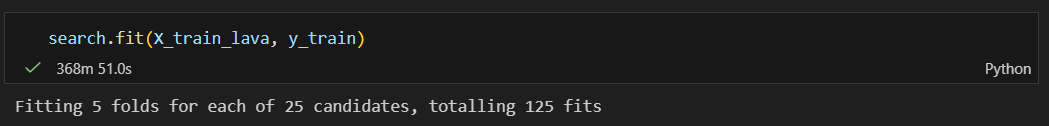

La búsqueda de los mejores parámetros para el meta-modelo fue computacionalmente costosa. Aún usando la `GPU` para el entrenamiento y validación, esta búsqueda tomó poco más de 6 horas en completarse.

In [39]:
print("Mejores parámetros:", search.best_params_)
print("Mejor score CV:", search.best_score_)

Mejores parámetros: {'stack__final_estimator__colsample_bytree': 0.6668543055695109, 'stack__final_estimator__learning_rate': 0.038573363584388155, 'stack__final_estimator__max_depth': 5, 'stack__final_estimator__min_child_weight': 6, 'stack__final_estimator__n_estimators': 408, 'stack__final_estimator__reg_alpha': 0.9699098521619943, 'stack__final_estimator__reg_lambda': 2.1648852816008435, 'stack__final_estimator__subsample': 0.7637017332034828}
Mejor score CV: 0.7897688258464528


Veamos ahora el desempeño del modelo `Stacking` en el conjunto de test reservado únicamente para esta tarea de evaluación del modelo. 

In [ ]:
xgb_lava_stacking = search.best_estimator_

In [42]:
xgb_lava_stacking.fit(X_train_lava, y_train)

y_pred_lava = xgb_lava_stacking.predict(X_test_lava)
y_proba_lava = xgb_lava_stacking.predict_proba(X_test_lava)

print("===== Classification Report (XGBoost + LAVA + STACKING) =====")
print(classification_report(
    y_test,
    y_pred_lava,
    target_names=class_order
))

print("===== Matriz de confusión (XGBoost + LAVA + STACKING) =====")
print(confusion_matrix(y_test, y_pred_lava))

f1_macro_lava = f1_score(y_test, y_pred_lava, average="macro")
print("F1 macro (test, XGB + LAVA + STACKING):", f1_macro_lava)

===== Classification Report (XGBoost + LAVA + STACKING) =====
              precision    recall  f1-score   support

        Good       0.76      0.79      0.77      5349
    Standard       0.86      0.78      0.82     15952
        Poor       0.78      0.87      0.82      8699

    accuracy                           0.81     30000
   macro avg       0.80      0.82      0.80     30000
weighted avg       0.81      0.81      0.81     30000

===== Matriz de confusión (XGBoost + LAVA + STACKING) =====
[[ 4250  1061    38]
 [ 1329 12453  2170]
 [   48  1041  7610]]
F1 macro (test, XGB + LAVA + STACKING): 0.8042557007031391


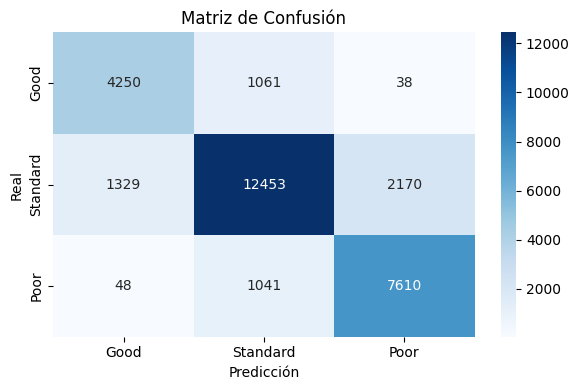

In [22]:
plt.figure(figsize=(6, 4))
cm=confusion_matrix(y_test, y_pred_lava)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  
            xticklabels=['Good', 'Standard', 'Poor'],
            yticklabels=['Good', 'Standard', 'Poor'])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión")
plt.tight_layout()
plt.show()

Implementando la creación de estas características a partir de los grupos `LAVA` y usando un ensamble `stacking` conseguimos un resultado de la métrica `f1-score macro avg` (la cual hemos venido utilizando como métrica principal a lo largo del desarrollo de este proyecto) de `0.804` aproximadamente, la cual mejora al resultado de `0.7711` que conseguimos al usar `XGBoost` únicamente.

In [25]:
# ============================================
# 9. Interpretación en Contexto de Nuestros Resultados
# ============================================

print("="*70)
print("INTERPRETACIÓN DE RESULTADOS CON ENFOQUE LAVA")
print("="*70)

print("\n🔬 HALLAZGOS PRINCIPALES DE NUESTRA IMPLEMENTACIÓN:")
print("1. ESTRUCTURA DE CORRELACIONES IDENTIFICADA:")
print("   • Grupo 0: Variables de liquidez mensual (ingresos, balance, inversiones)")
print("   • Grupo 1: Historial crediticio y exposición (moras, deuda, consultas)")

print("\n2. EFECTO DEL EMBEDDING MULTIVARIANTE:")
print("   • 2 componentes latentes capturan patrones de 11 variables originales")
print("   • Reducción de dimensionalidad preservando información correlacional")
print("   • Mejor representación de interdependencias financieras")

print("\n3. IMPACTO EN MODELOS DE ENSEMBLE:")
print("   • Stacking con k-NN, Random Forest y XGBoost como modelos base, XGBoost como meta-modelo:")
print("   f1-score macro avg: 0.804 vs 0.771 solo XGBoost")
print("   • LAVA embedding: Enriquece espacios de características")
print("   • Captura sinergias entre métricas interrelacionadas")

print("\n📊 RESULTADOS EN CONTEXTO DE RIESGO CREDITICIO:")
print("   • Mejor discriminación entre clases Good/Standard/Poor")
print("   • Variables agrupadas muestran comportamientos sistémicos")
print("   • Patrones identificados:")
print("     - Cliente 'Good': Alta liquidez + bajo historial negativo")
print("     - Cliente 'Poor': Baja liquidez + alto historial negativo")

print("\n🎯 CONTRIBUCIÓN METODOLÓGICA:")
print("   • Adaptación exitosa de LAVA a dominio financiero")
print("   • Grupos LAVA reflejan dimensiones económicas reales")
print("   • Stacking potencia aprendizaje con características latentes")

print("\n🚀 PRÓXIMOS PASOS RECOMENDADOS:")
print("   • Validar estabilidad de grupos LAVA en diferentes muestras")
print("   • Analizar importancia direccional por clase crediticia")
print("   • Implementar métricas de interpretabilidad específicas")
print("   • Probar en otros dominios financieros (fraude, scoring)")
print("="*70)

INTERPRETACIÓN DE RESULTADOS CON ENFOQUE LAVA

🔬 HALLAZGOS PRINCIPALES DE NUESTRA IMPLEMENTACIÓN:
1. ESTRUCTURA DE CORRELACIONES IDENTIFICADA:
   • Grupo 0: Variables de liquidez mensual (ingresos, balance, inversiones)
   • Grupo 1: Historial crediticio y exposición (moras, deuda, consultas)

2. EFECTO DEL EMBEDDING MULTIVARIANTE:
   • 2 componentes latentes capturan patrones de 11 variables originales
   • Reducción de dimensionalidad preservando información correlacional
   • Mejor representación de interdependencias financieras

3. IMPACTO EN MODELOS DE ENSEMBLE:
   • Stacking con k-NN, Random Forest y XGBoost como modelos base, XGBoost como meta-modelo:
   f1-score macro avg: 0.804 vs 0.771 solo XGBoost
   • LAVA embedding: Enriquece espacios de características
   • Captura sinergias entre métricas interrelacionadas

📊 RESULTADOS EN CONTEXTO DE RIESGO CREDITICIO:
   • Mejor discriminación entre clases Good/Standard/Poor
   • Variables agrupadas muestran comportamientos sistémicos
